# 🎓 Demo Bảo vệ — Quanvolution trên BreastMNIST

**Luồng trình chiếu:** Ảnh siêu âm vú gốc → mạch lượng tử 4-qubit (live) tạo 4 kênh feature map → head cổ điển đối xứng train trên feature đã precompute → dự đoán + xác suất → so chi phí suy luận.

*Mọi con số tái lập từ ground truth `results/full_trainable_breastmnist.json` (10 seeds × 20 epochs). Nhãn: `0` = malignant (ác tính), `1` = benign (lành tính).*

In [1]:
import os, sys, time, json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from src.models.circuits import CIRCUIT_DICT, apply_quanv_to_image
from src.models.quantum_model import QuanvolutionClassifier
from src.models.classical_cnn import SymmetricalMinimumCNN

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(os.cpu_count())
plt.rcParams['figure.dpi'] = 110
print('Repo root:', ROOT)
print('PyTorch', torch.__version__)

Repo root: D:\KhoaLuanTotNghiep
PyTorch 2.5.1+cu121


In [2]:
# ---- Nạp BreastMNIST test set (chuẩn MedMNIST: npz; tự tải nếu thiếu) ----
NPZ = ROOT / 'data' / 'breastmnist.npz'
if not NPZ.exists():
    import medmnist
    print('Đang tải breastmnist.npz (lần đầu, ~1 MB)...')
    medmnist.BreastMNIST(split='test', download=True, root=str(ROOT / 'data'))

d = np.load(NPZ)
test_imgs = d['test_images'].astype(np.float32) / 255.0     # (156, 28, 28) in [0,1]
test_labels = d['test_labels'].astype(np.int64).ravel()      # 0=malignant, 1=benign
print('Test set:', test_imgs.shape, '| malignant:', int((test_labels==0).sum()),
      '| benign:', int((test_labels==1).sum()))

Test set: (156, 28, 28) | malignant: 42 | benign: 114


Train 20 epochs trong 1.3s | best val AUC = 0.8480
Test (1 seed demo): Accuracy = 0.7821 | ROC-AUC = 0.8404
Paper (10 seeds):   Accuracy = 0.8083 ± 0.0279 | ROC-AUC = 0.8521 ± 0.0095


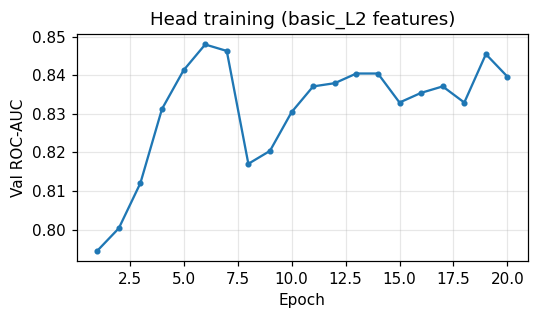

Ảnh demo: index 6 | nhãn thật = 0 (malignant) | p(malignant) = 0.884 — phân loại đúng


In [3]:
# ---- Train head cổ điển ĐỐI XỨNG trên feature đã precompute (mạch basic_L2) ----
# Protocol giống paper: QuanvolutionClassifier = BatchNorm2d(4) -> ReLU -> Linear(784,2)
# CE loss, Adam lr=0.001, 20 epochs, chọn checkpoint theo best val ROC-AUC.
def load_split(circuit, split):
    feats, labels = torch.load(f'data/quantum_features/breastmnist_{circuit}_{split}.pt',
                               map_location='cpu', weights_only=False)
    return torch.utils.data.TensorDataset(torch.as_tensor(feats, dtype=torch.float32),
                                          torch.as_tensor(labels, dtype=torch.long))

torch.manual_seed(SEED)
tr_ds  = load_split('basic_L2', 'train')
va_ds  = load_split('basic_L2', 'val')
te_ds  = load_split('basic_L2', 'test')
g = torch.Generator().manual_seed(SEED)
tr_loader = torch.utils.data.DataLoader(tr_ds, batch_size=32, shuffle=True, generator=g)
va_loader = torch.utils.data.DataLoader(va_ds, batch_size=64)
te_loader = torch.utils.data.DataLoader(te_ds, batch_size=64)

head = QuanvolutionClassifier(num_classes=2)
crit = nn.CrossEntropyLoss()
opt = optim.Adam(head.parameters(), lr=0.001)

def eval_auc(model, loader):
    from sklearn.metrics import roc_auc_score
    model.eval(); ys, ps = [], []
    with torch.no_grad():
        for x, y in loader:
            p = torch.softmax(model(x), 1)[:, 1]
            ys.append(y); ps.append(p)
    return roc_auc_score(torch.cat(ys), torch.cat(ps))

t0 = time.perf_counter()
best_auc, best_state = -1, None
hist = []
for ep in range(1, 21):
    head.train()
    for x, y in tr_loader:
        opt.zero_grad(); loss = crit(head(x), y); loss.backward(); opt.step()
    va = eval_auc(head, va_loader)
    hist.append(va)
    if va > best_auc:
        best_auc, best_state = va, {k: v.clone() for k, v in head.state_dict().items()}
train_time = time.perf_counter() - t0
head.load_state_dict(best_state)

from sklearn.metrics import accuracy_score, roc_auc_score
head.eval(); ys, ps = [], []
with torch.no_grad():
    for x, y in te_loader:
        ps.append(torch.softmax(head(x), 1)); ys.append(y)
probs = torch.cat(ps); labels_t = torch.cat(ys)
preds = probs.argmax(1).numpy()
acc = accuracy_score(labels_t, preds)
auc = roc_auc_score(labels_t, probs[:, 1].numpy())
print(f'Train 20 epochs trong {train_time:.1f}s | best val AUC = {best_auc:.4f}')
print(f'Test (1 seed demo): Accuracy = {acc:.4f} | ROC-AUC = {auc:.4f}')
print('Paper (10 seeds):   Accuracy = 0.8083 ± 0.0279 | ROC-AUC = 0.8521 ± 0.0095')

plt.figure(figsize=(5, 3))
plt.plot(range(1, 21), hist, marker='o', ms=3)
plt.xlabel('Epoch'); plt.ylabel('Val ROC-AUC'); plt.title('Head training (basic_L2 features)')
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

# Chọn ảnh demo CÔNG KHAI: trường hợp ác tính được head phân loại ĐÚNG, tin cậy cao nhất
mal_idx = np.where(test_labels == 0)[0]
DEMO_IDX = int(mal_idx[np.argmax(probs[mal_idx, 0].numpy())])
img = test_imgs[DEMO_IDX]
true_label = int(test_labels[DEMO_IDX])
print(f'Ảnh demo: index {DEMO_IDX} | nhãn thật = {true_label} (malignant) | '
      f'p(malignant) = {float(probs[DEMO_IDX, 0]):.3f} — phân loại đúng')

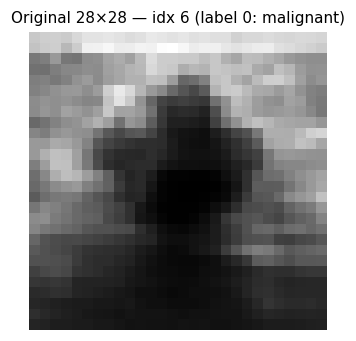

In [4]:
# ---- Ảnh siêu âm gốc 28x28 ----
fig, ax = plt.subplots(figsize=(3.2, 3.2))
ax.imshow(img, cmap='gray')
ax.set_title(f'Original 28×28 — idx {DEMO_IDX} (label {true_label}: malignant)', fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.show()

Thời gian trích xuất 1 ảnh / 1 mạch: 283.5 ms


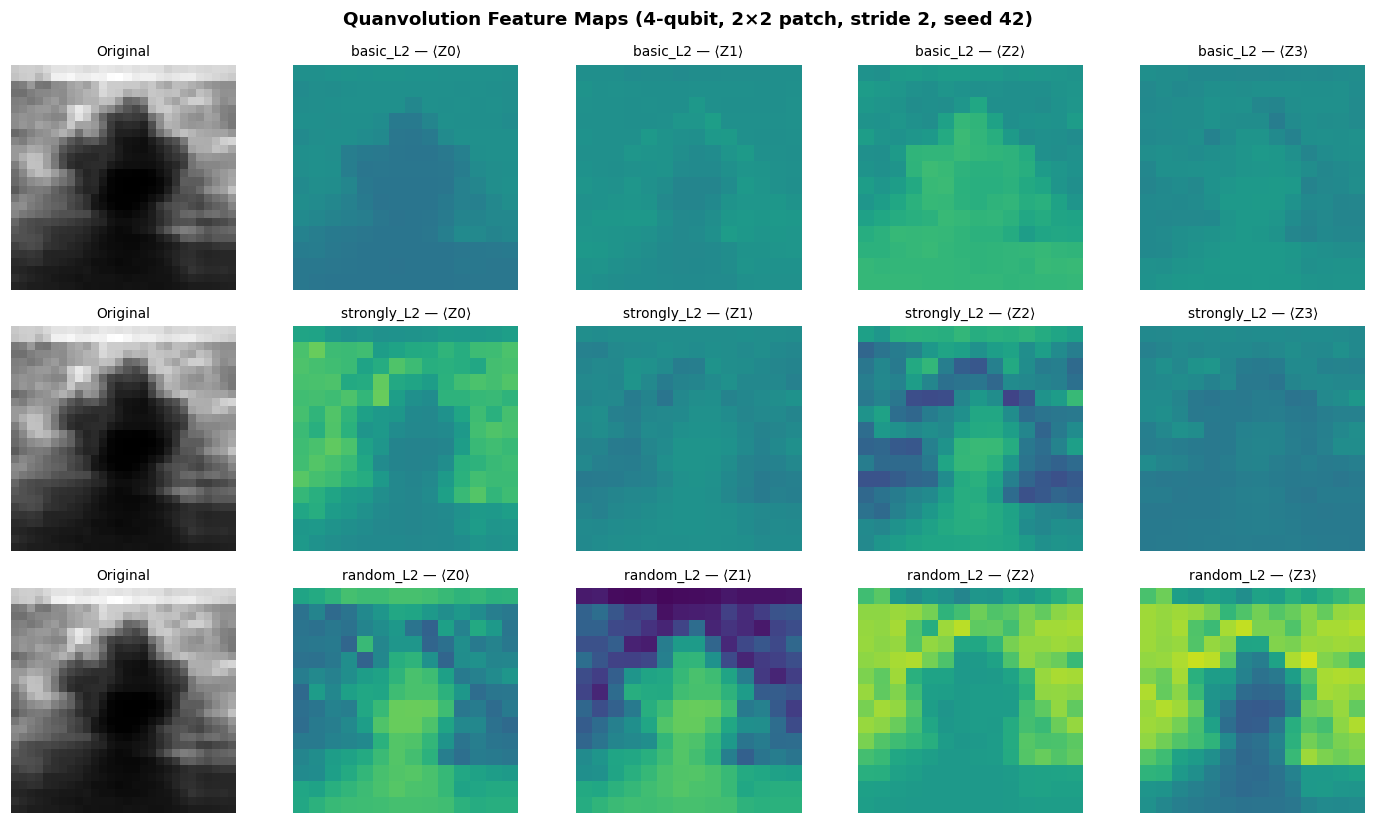

In [5]:
# ---- LIVE: 3 mạch lượng tử tĩnh quét 196 patches -> 4 kênh feature map ----
CIRCUITS = ['basic_L2', 'strongly_L2', 'random_L2']
feat_live, t_quanv = {}, 0.0
for name in CIRCUITS:
    t0 = time.perf_counter()
    feat_live[name] = apply_quanv_to_image(img[None, :, :], CIRCUIT_DICT[name])
    t_quanv += time.perf_counter() - t0
t_quanv /= len(CIRCUITS)
print(f'Thời gian trích xuất 1 ảnh / 1 mạch: {t_quanv*1000:.1f} ms')

fig, axes = plt.subplots(3, 5, figsize=(13, 7.6))
for r, name in enumerate(CIRCUITS):
    fm = feat_live[name]
    axes[r, 0].imshow(img, cmap='gray')
    axes[r, 0].set_title(f'Original', fontsize=9)
    for c in range(4):
        axes[r, c+1].imshow(fm[c], cmap='viridis', vmin=-1, vmax=1)
        axes[r, c+1].set_title(f'{name} — ⟨Z{c}⟩', fontsize=9)
    for c in range(5):
        axes[r, c].axis('off')
plt.suptitle('Quanvolution Feature Maps (4-qubit, 2×2 patch, stride 2, seed 42)', fontweight='bold')
plt.tight_layout()
plt.show()

Nhãn thật     : 0 (malignant)
Dự đoán       : 0 (malignant)
Xác suất      : malignant = 0.884 | benign = 0.116
Khớp feature precompute (max abs diff): 1.47e-08


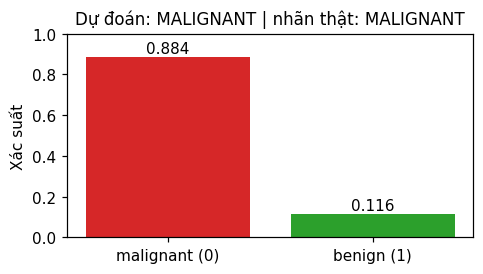

In [6]:
# ---- DỰ ĐOÁN trên chính ảnh demo (dùng LIVE features, không peek test set loader) ----
x = torch.as_tensor(feat_live['basic_L2'], dtype=torch.float32).unsqueeze(0)  # (1,4,14,14)
with torch.no_grad():
    p = torch.softmax(head(x), 1)[0]
pred = int(p.argmax())
print(f'Nhãn thật     : {true_label} (malignant)')
print(f'Dự đoán       : {pred} ({"malignant" if pred==0 else "benign"})')
print(f'Xác suất      : malignant = {p[0]:.3f} | benign = {p[1]:.3f}')

# Kiểm tra nhất quán: feature tính LIVE == feature đã precompute cho cùng ảnh?
te_feats, te_labels_chk = torch.load('data/quantum_features/breastmnist_basic_L2_test.pt',
                                 map_location='cpu', weights_only=False)
diff = float(np.abs(np.asarray(te_feats[DEMO_IDX]) - feat_live['basic_L2']).max())
print(f'Khớp feature precompute (max abs diff): {diff:.2e}')

fig, ax = plt.subplots(figsize=(4.5, 2.6))
bars = ax.bar(['malignant (0)', 'benign (1)'], p.numpy(), color=['#d62728', '#2ca02c'])
ax.set_ylim(0, 1); ax.set_ylabel('Xác suất')
ax.set_title(f'Dự đoán: {"MALIGNANT" if pred==0 else "BENIGN"} | nhãn thật: {"MALIGNANT" if true_label==0 else "BENIGN"}', fontsize=11)
for b, v in zip(bars, p.numpy()):
    ax.text(b.get_x()+b.get_width()/2, v+.02, f'{v:.3f}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

In [7]:
# ---- Chi phí suy luận: Classical CNN vs Quanvolution (CPU) ----
cnn = SymmetricalMinimumCNN(num_classes=2).eval()
ximg = torch.as_tensor(img, dtype=torch.float32)[None, None]  # (1,1,28,28)
with torch.no_grad():
    _ = cnn(ximg)
    reps = 20
    t0 = time.perf_counter()
    for _ in range(reps):
        _ = cnn(ximg)
    t_cnn = (time.perf_counter()-t0)/reps*1000
    _ = apply_quanv_to_image(img[None], CIRCUIT_DICT['basic_L2'])
    reps_q = 3
    t0 = time.perf_counter()
    for _ in range(reps_q):
        _ = apply_quanv_to_image(img[None], CIRCUIT_DICT['basic_L2'])
    t_q = (time.perf_counter()-t0)/reps_q*1000
print(f'Classical CNN forward : {t_cnn:8.3f} ms/ảnh  (1.0x)')
print(f'Quanvolution (CPU)    : {t_q:8.1f} ms/ảnh  (~{t_q/max(t_cnn,1e-9):.0f}x chậm hơn)')
print('Paper: 0.310 ms vs 220.22 ms (~710x) — cùng bậc, khác biệt do CPU/PennyLane version')

Classical CNN forward :    0.207 ms/ảnh  (1.0x)
Quanvolution (CPU)    :    268.2 ms/ảnh  (~1293x chậm hơn)
Paper: 0.310 ms vs 220.22 ms (~710x) — cùng bậc, khác biệt do CPU/PennyLane version


## 📌 Tổng kết demo
| Ý | Bằng chứng trong demo |
|---|---|
| **Quantum Inductive Bias 0 tham số** | 3 mạch tĩnh (seed 42, khóa góc) tạo feature map hữu ích — kernel 0 trainable params |
| **Head đối xứng 1:1** | `BatchNorm2d(4) → ReLU → Linear(784,2)` — giống hệt baseline CNN |
| **Trainable cục bộ** | Head train 20 epochs trong vài giây trên feature precompute (18 s/10 seeds trong paper) |
| **Chi phí** | Quanvolution chậm hàng trăm lần trên CPU → chiến lược precompute |
| **Kết quả trung thực** | BreastMNIST: quantum thắng ROC-AUC/PR-AUC; OCTMNIST: CNN thắng — *data-regime dependent* |
